In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/ncr_ride_bookings.csv')

In [ ]:
# Menghitung frekuensi setiap kategori
payment_counts = df['Payment Method'].value_counts()
print("Hasil perhitungan frekuensi metode pembayaran:")
print(payment_counts)

Hasil perhitungan frekuensi metode pembayaran:
Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64


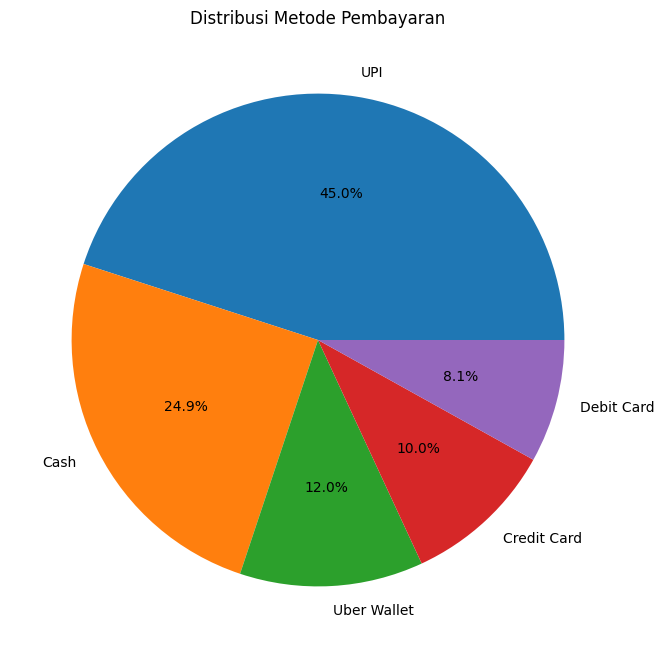

In [ ]:
# Contoh: Pie Chart yang "kurang tepat"
plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Distribusi Metode Pembayaran')
plt.show()

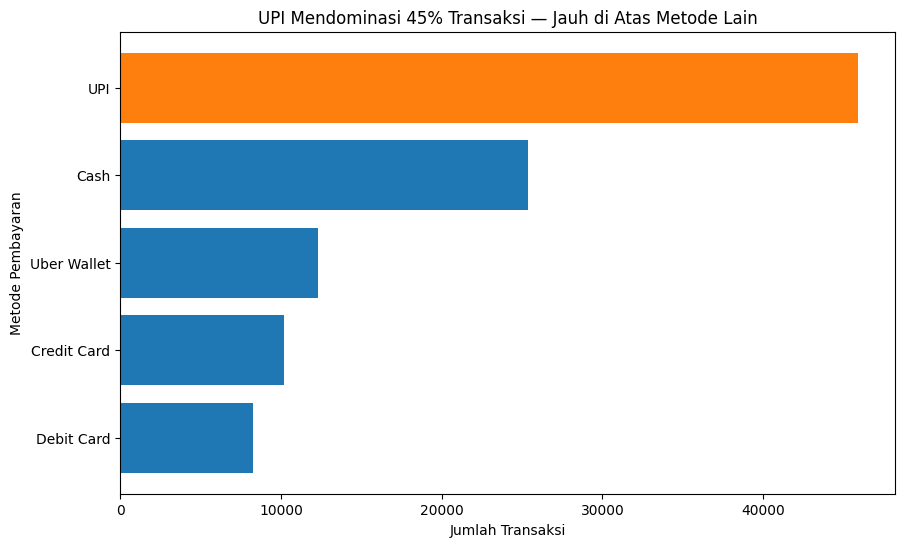

In [ ]:
# Perbaikan: Bar chart horizontal + judul insight + warna strategis
plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if x != 'UPI' else '#ff7f0e' for x in payment_counts.index]  # UPI di-highlight
plt.barh(payment_counts.index, payment_counts.values, color=colors)
plt.title('UPI Mendominasi 45% Transaksi — Jauh di Atas Metode Lain')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Metode Pembayaran')
plt.gca().invert_yaxis()  # Urutkan dari atas: UPI paling atas
plt.show()

## Contoh Keputusan
1. Tambah fitur integrasi dengan sistem UPI, scan barcode -> Mempermudah pembayaran dengan UPI.
2. Promo/Cashback dengan sistem UPI.
3. Jenis Pembyaran lain tidak perlu di gembar gemborkan, karena biaya operasional dan kerja sama yang mahal, meningkat efisiensi.


Umumnya dengan Scatter Plot


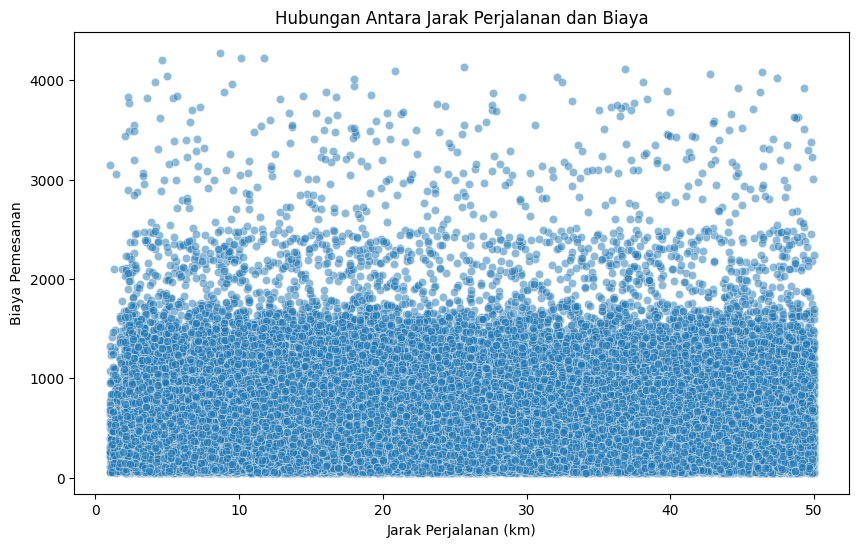

In [ ]:
# Scatter Plot
print("\nUmumnya dengan Scatter Plot")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ride Distance', y='Booking Value', data=df, alpha=0.5)
plt.title('Hubungan Antara Jarak Perjalanan dan Biaya')
plt.xlabel('Jarak Perjalanan (km)')
plt.ylabel('Biaya Pemesanan')
plt.show()

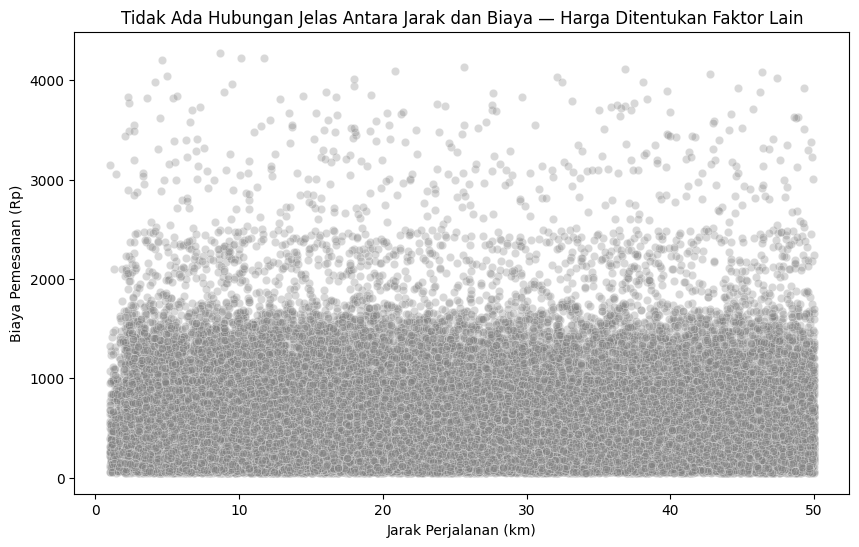

In [ ]:
# Modul 5: Tambahkan insight & kurangi noise
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ride Distance', y='Booking Value', data=df, alpha=0.3, color='gray')
plt.title('Tidak Ada Hubungan Jelas Antara Jarak dan Biaya — Harga Ditentukan Faktor Lain')
plt.xlabel('Jarak Perjalanan (km)')
plt.ylabel('Biaya Pemesanan (Rp)')
plt.show()

## Contoh Keputusan
1. Melakukan transparansi harga ke customer.

Faktor Lain (area penjemputan, jam, hujan/tidak).


Pendekatan yang Lebih Baik (Histogram)


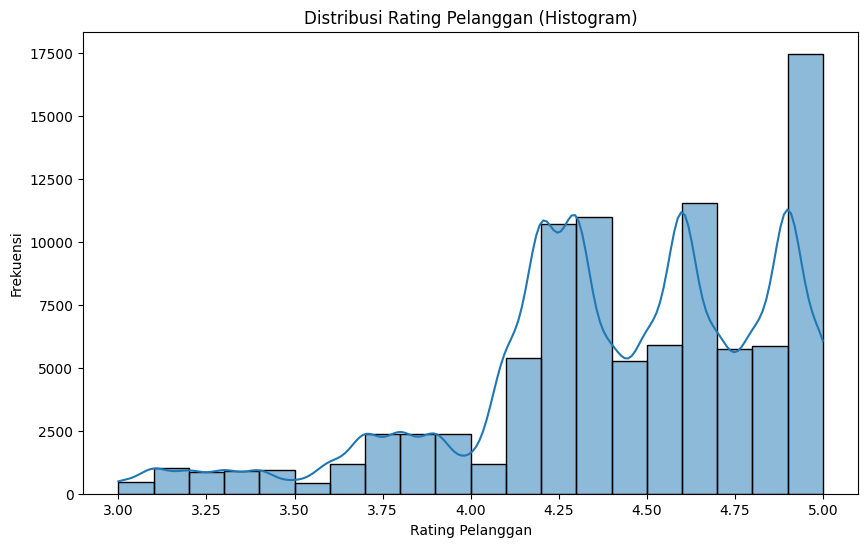

In [ ]:
# Pendekatan yang Lebih Baik: Histogram
print("\nPendekatan yang Lebih Baik (Histogram)")
plt.figure(figsize=(10, 6))
sns.histplot(df['Customer Rating'], bins=20, kde=True)
plt.title('Distribusi Rating Pelanggan (Histogram)')
plt.xlabel('Rating Pelanggan')
plt.ylabel('Frekuensi')
plt.show()

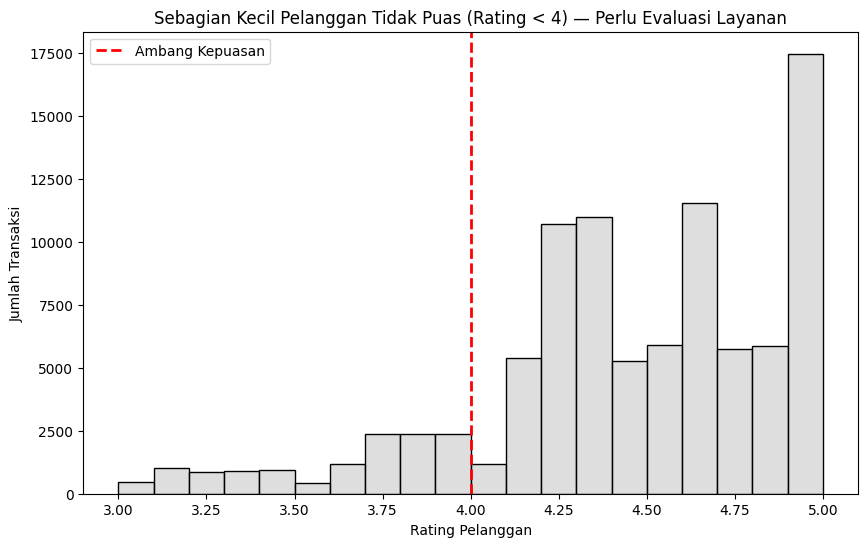

In [ ]:
plt.figure(figsize=(10, 6))
# Gunakan warna netral + highlight area "tidak puas"
sns.histplot(df['Customer Rating'], bins=20, color='lightgray', edgecolor='black')

# Tambahkan garis vertikal di rating = 4 (ambang "puas")
plt.axvline(x=4, color='red', linestyle='--', linewidth=2, label='Ambang Kepuasan')

# Judul = insight
plt.title('Sebagian Kecil Pelanggan Tidak Puas (Rating < 4) — Perlu Evaluasi Layanan')
plt.xlabel('Rating Pelanggan')
plt.ylabel('Jumlah Transaksi')
plt.legend()
plt.show()

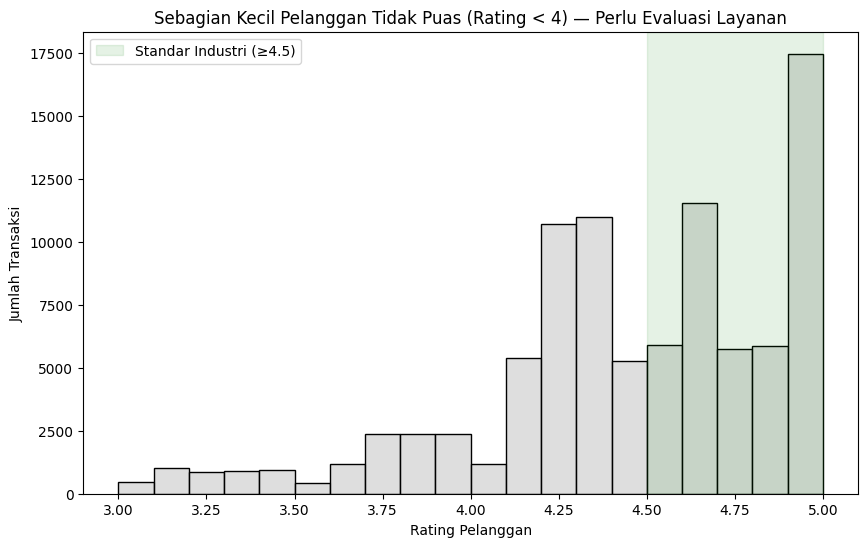

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Customer Rating'], bins=20, color='lightgray', edgecolor='black')

# Tambahkan area background untuk menunjukkan "standar industri" (misal: rating ≥4.5 = baik)
plt.axvspan(4.5, 5.0, color='green', alpha=0.1, label='Standar Industri (≥4.5)')

plt.title('Sebagian Kecil Pelanggan Tidak Puas (Rating < 4) — Perlu Evaluasi Layanan')
plt.xlabel('Rating Pelanggan')
plt.ylabel('Jumlah Transaksi')
plt.legend()
plt.show()


Perbandingan Tipe Kendaraan dengan Boxplot


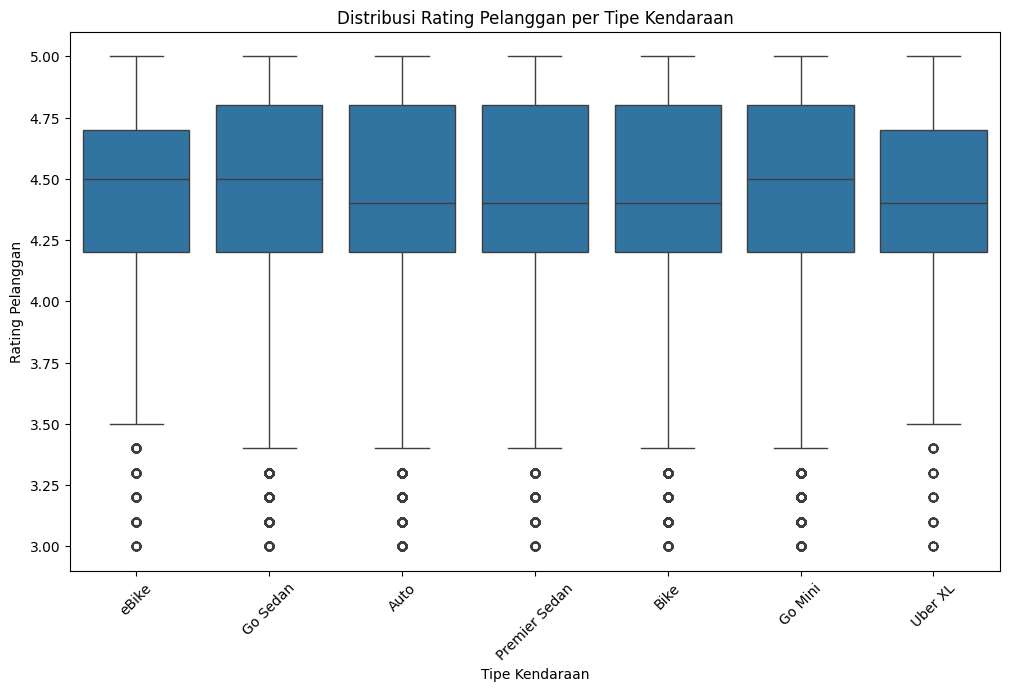

In [ ]:
# Boxplot di Modul 4
print("\nPerbandingan Tipe Kendaraan dengan Boxplot")
plt.figure(figsize=(12, 7))
sns.boxplot(x='Vehicle Type', y='Customer Rating', data=df)
plt.title('Distribusi Rating Pelanggan per Tipe Kendaraan')
plt.xlabel('Tipe Kendaraan')
plt.ylabel('Rating Pelanggan')
plt.xticks(rotation=45)
plt.show()

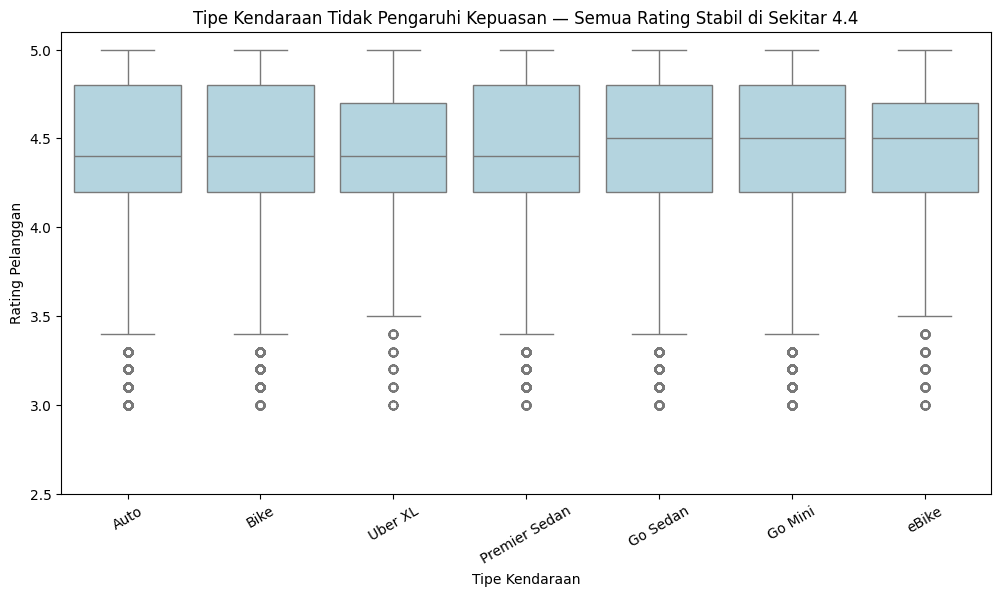

In [ ]:
plt.figure(figsize=(12, 6))
# Urutkan berdasarkan median (dari rendah ke tinggi)
order = df.groupby('Vehicle Type')['Customer Rating'].median().sort_values().index
sns.boxplot(x='Vehicle Type', y='Customer Rating', data=df, order=order, color='lightblue')

# Judul = insight negatif yang valid
plt.title('Tipe Kendaraan Tidak Pengaruhi Kepuasan — Semua Rating Stabil di Sekitar 4.4')
plt.xlabel('Tipe Kendaraan')
plt.ylabel('Rating Pelanggan')
plt.xticks(rotation=30)
plt.grid(False)  # Hapus grid
plt.ylim(2.5, 5.1)  # Zoom ke area relevan (rating 3–5)
plt.show()